In [3]:
from pathlib import Path
import sys

SERVER_PROJECT_ROOT = Path('~/workspace/paper_research').expanduser().resolve()
if str(SERVER_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVER_PROJECT_ROOT))

from utils.notebook_bootstrap import bootstrap_notebook

PROJECT_ROOT, DIR = bootstrap_notebook(preferred_root=SERVER_PROJECT_ROOT)


PROJECT_ROOT = /home/leekwanhyeong/workspace/paper_research


In [1]:

import torch
import os, sys
import polars as pl


sys.path.insert(0, os.path.abspath(".."))


MAC_DIR = '/Users/igwanhyeong/PycharmProjects/paper_research/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/paper_research/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

# Data Preprocess

## 1. Interpolate part's sequence

### Goal
- 자재(`oper_part_no`)별로 주차(`demand_dt = yyyyww`) 시계열이 **중간에 누락된 주차가 존재**할 수 있음
- 누락 구간을 **주차 단위로 연속 인덱스(weekly index)** 로 보간(interpolation)하여,
  - 모든 자재가 **동일한 규칙(매주 1개 timestep)** 을 갖도록 정규화
  - 이후 모델 학습/분석에서 **seq(순번), 누락주 처리, 0-demand 구간 처리**를 일관되게 수행 가능하게 함

---

### Methodology

- `demand_dt(yyyyww)` 를 **ISO week 기반 Monday(date)** 로 변환
  - `yyyyww_to_monday(yyyyww)` 사용
  - `date.fromisocalendar(year, week, 1)` → 해당 주차의 월요일 반환
- 자재별(`oper_part_no`)로 관측된 `demand_date`의 **min~max 구간**을 계산
- 각 자재별 min~max 사이에 대해 **주 단위(1w) date_range 생성**
  - `pl.date_range(min_date, max_date, interval='1w', closed='both')`
- 생성된 full weekly index를 explode 하여 **(oper_part_no, demand_date)** 레벨의 완전한 시계열 인덱스 테이블 구성
- 원본 데이터(df2)와 full index를 **left join** 하여 누락 주차를 포함한 전체 시계열 구성
  - 누락된 `demand_qty`는 `0.0`으로 fill
- `demand_date(Monday)` 를 다시 `yyyyww` 로 역변환
  - `monday_to_yyyyww(date)` 사용
  - `d.isocalendar()` 기반으로 `year*100 + week`
- 자재별로 누적 순번 `seq` 생성
  - `pl.cum_count('oper_part_no').over('oper_part_no')`
  - 각 자재 내에서 `0..T-1` 형태의 timestep index 역할
---

In [9]:
from datetime import date
def yyyyww_to_monday(yyyyww: int) -> date:
    y = yyyyww // 100
    w = yyyyww % 100
    return date.fromisocalendar(y, w, 1)

def monday_to_yyyyww(d: date) -> int:
    iso = d.isocalendar()
    return int(iso.year) * 100 + int(iso.week)


df = (pl
    .read_parquet(DIR + 'sample_data/tb_master_target.parquet')
    .sort(['oper_part_no', 'demand_dt'])
 )

df2 = (
    df.with_columns(
        pl.col('demand_dt')
          .map_elements(yyyyww_to_monday, return_dtype = pl.Date)
          .alias('demand_date')
    )
)

full_index = (
    df2.group_by('oper_part_no')
       .agg(
            pl.date_range(
                pl.col('demand_date').min(),
                pl.col('demand_date').max(),
                interval = '1w',
                closed = 'both',
                eager = False,
            ).alias('demand_date')
    )
    .explode('demand_date')
)

out = (
    full_index
        .join(df2.select(['oper_part_no', 'demand_date', 'demand_qty']),
              on = ['oper_part_no', 'demand_date'],
              how = 'left'
              )
        .with_columns(
            pl.col('demand_qty').fill_null(0.0),
            pl.col('demand_date')
              .map_elements(monday_to_yyyyww, return_dtype = pl.Int64)
              .alias('demand_dt'),
            pl.cum_count('oper_part_no').over('oper_part_no').alias('seq')
        )
        .select(['oper_part_no', 'demand_dt', 'demand_qty', 'seq'])
        .sort(['oper_part_no', 'demand_dt'])
)

out

oper_part_no,demand_dt,demand_qty,seq
str,i64,f64,u32
"""DS_A001""",202029,4.0,1
"""DS_A001""",202030,2.0,2
"""DS_A001""",202031,2.0,3
"""DS_A001""",202032,5.0,4
"""DS_A001""",202033,1.0,5
…,…,…,…
"""DS_Z999""",202611,3.0,316
"""DS_Z999""",202612,8.0,317
"""DS_Z999""",202613,9.0,318


## Select Intermittent Parts using intermittent detector.

In [28]:
from utils.intermittent_detector import IntermittentConfig, IntermittentDetector

intermittent_config = IntermittentConfig(
    id_col="oper_part_no",
    date_col="demand_dt",
    y_col="demand_qty",
    seq_col="seq",
    epsilon=8.0,        # trace demand를 0으로 간주
    adi_threshold=5.0,
    cv2_threshold=0.2,
    min_periods=10,
)

result = IntermittentDetector(
    freq = 'weekly',
    config = intermittent_config,
).run(df = out, return_stats = True )

result

oper_part_no,demand_type,is_sparsity,n_periods,n_zero,n_nz,zero_ratio,ADI,CV,CV2,mean_nonzero_gap,median_nonzero_gap,nz_mean,nz_std,freq
str,str,bool,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,str
"""DS_AO500""","""erratic""",false,96,11,85,0.114583,1.129412,1.407024,1.979716,1.130952,1.0,33.058824,46.514553,"""weekly"""
"""DS_N808""","""smooth""",false,129,83,46,0.643411,2.804348,0.40287,0.162305,1.622222,1.0,22.5,9.064583,"""weekly"""
"""DS_R894""","""erratic""",false,164,6,158,0.036585,1.037975,0.454025,0.206138,1.031847,1.0,40.626582,18.445473,"""weekly"""
"""DS_AE494""","""erratic""",false,209,43,166,0.205742,1.259036,1.628654,2.652513,1.169697,1.0,25.349398,41.285388,"""weekly"""
"""DS_AK341""","""lumpy""",true,338,279,59,0.825444,5.728814,0.496029,0.246045,1.275862,1.0,29.881356,14.82203,"""weekly"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DS_A811""","""intermittent""",true,438,385,53,0.878995,8.264151,0.38386,0.147348,6.0,1.0,35.264151,13.53649,"""weekly"""
"""DS_K420""","""intermittent""",true,338,293,45,0.866864,7.511111,0.367521,0.135072,7.113636,1.0,27.777778,10.208929,"""weekly"""
"""DS_L232""","""lumpy""",true,194,157,37,0.809278,5.243243,0.496404,0.246417,4.777778,1.0,41.378378,20.540409,"""weekly"""


## Filter Intermittent parts & See Plots

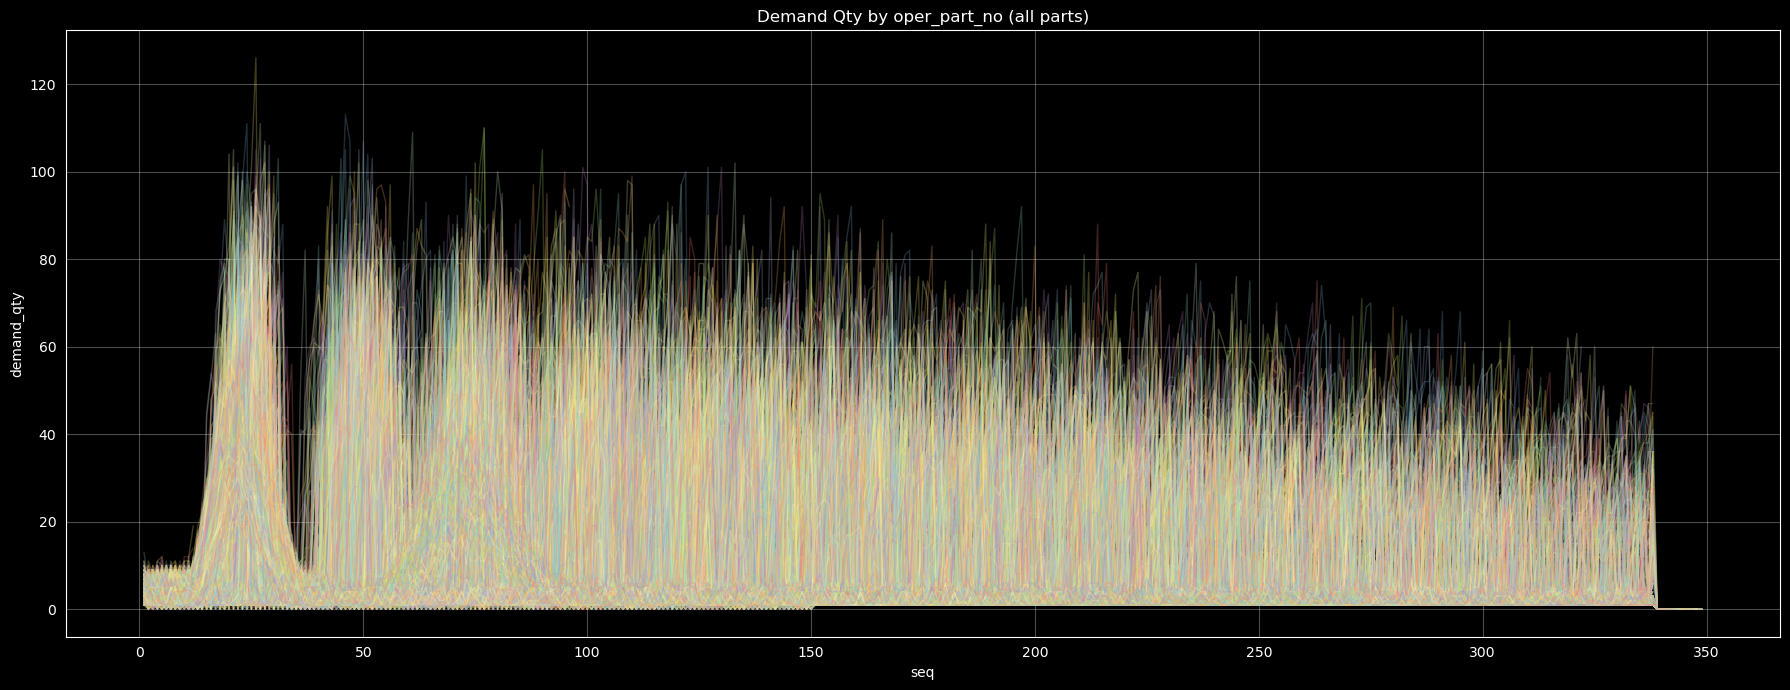

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

intermittent_parts = result.filter(pl.col('demand_type') == 'intermittent').select('oper_part_no').unique()


intermittent_df = out.join(intermittent_parts, on = 'oper_part_no', how = 'right')
test_parts = intermittent_df.group_by('oper_part_no').agg([pl.col('seq').max().alias('max_seq')]).filter(pl.col('max_seq') < 350).select('oper_part_no').unique()

intermittent_df = intermittent_df.join(test_parts, on = 'oper_part_no', how = 'right')

pdf = intermittent_df.to_pandas()
pdf = pdf.sort_values(['oper_part_no', 'seq'])
fig, ax = plt.subplots(figsize = (18, 7))
for part, g in pdf.groupby('oper_part_no', sort = False):
    ax.plot(g['seq'].values, g['demand_qty'].values, linewidth = 1, alpha = 0.25)

ax.set_title('Demand Qty by oper_part_no (all parts)')
ax.set_xlabel('seq')
ax.set_ylabel('demand_qty')
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

## Making Marker DataFrame

In [42]:
from utils.magnitude_pipeline import compare_scale_bases, build_magnitude_marked_df

# 1) 먼저 base별 mark 분포 확인
compare_info = compare_scale_bases(
    intermittent_df,
    log_bases=(10.0, 4.0, 2.0),
)

compare_info["summary"], compare_info["raw_distribution"]

(shape: (3, 5)
 ┌──────────┬─────────────────┬────────────┬─────────────────────┬────────────┐
 │ log_base ┆ num_raw_classes ┆ head_ratio ┆ suggested_max_order ┆ tail_count │
 │ ---      ┆ ---             ┆ ---        ┆ ---                 ┆ ---        │
 │ f64      ┆ i64             ┆ f64        ┆ i64                 ┆ i64        │
 ╞══════════╪═════════════════╪════════════╪═════════════════════╪════════════╡
 │ 2.0      ┆ 7               ┆ 0.44486    ┆ 6                   ┆ 0          │
 │ 4.0      ┆ 4               ┆ 0.692683   ┆ 3                   ┆ 0          │
 │ 10.0     ┆ 3               ┆ 0.890132   ┆ 2                   ┆ 0          │
 └──────────┴─────────────────┴────────────┴─────────────────────┴────────────┘,
 shape: (14, 5)
 ┌──────────┬───────────┬─────────┬──────────┬───────────┐
 │ log_base ┆ raw_order ┆ len     ┆ ratio    ┆ cum_ratio │
 │ ---      ┆ ---       ┆ ---     ┆ ---      ┆ ---       │
 │ f64      ┆ i32       ┆ u32     ┆ f64      ┆ f64       │
 ╞══════════

In [47]:
EVENT_EPSILON = 8.0
MAX_INSIDE_BURST_GAP = 3

ev = (
    intermittent_df
    .filter(pl.col("demand_qty") > EVENT_EPSILON)
    .sort(["oper_part_no", "seq"])
    .with_columns(
        (pl.col("seq") - pl.col("seq").shift(1).over("oper_part_no")).alias("_gap")
    )
    .with_columns(
        pl.when(pl.col("_gap").is_null() | (pl.col("_gap") > MAX_INSIDE_BURST_GAP))
          .then(1)
          .otherwise(0)
          .alias("_new_episode")
    )
    .with_columns(
        pl.col("_new_episode").cum_sum().over("oper_part_no").alias("_episode_id")
    )
)

episode_df = (
    ev.group_by(["oper_part_no", "_episode_id"])
      .agg([
          pl.col("demand_dt").first().alias("demand_dt"),
          pl.col("seq").first().alias("seq"),
          pl.col("demand_qty").sum().alias("demand_qty"),
      ])
      .sort(["oper_part_no", "seq"])
)

valid_parts = (
    episode_df.group_by("oper_part_no")
    .len()
    .filter(pl.col("len") >= 2)
    .select("oper_part_no")
)

episode_df = episode_df.join(valid_parts, on="oper_part_no", how="inner")

from utils.magnitude_pipeline import build_magnitude_marked_df

marked_df, marked_meta = build_magnitude_marked_df(
    episode_df,
    scale_base=2.0,
    min_order=0,
    clip_min_qty=1.0,
)

In [48]:
marked_df.select(
    pl.col("delta_t").min().alias("dt_min"),
    pl.col("delta_t").median().alias("dt_median"),
    pl.col("delta_t").max().alias("dt_max"),
    pl.col("demand_qty").min().alias("qty_min"),
    pl.col("demand_qty").median().alias("qty_median"),
    pl.col("demand_qty").max().alias("qty_max"),
)

dt_min,dt_median,dt_max,qty_min,qty_median,qty_max
i32,f64,i32,f64,f64,f64
0,24.0,58,9.0,112.0,1095.0


In [55]:
marked_df.write_parquet(DIR + 'sample_data/marked_target_df.parquet')